# EX 1 :


In [ ]:
import torch

A = torch.tensor([[1, 2], [-2, 0], [3, 4]], dtype=torch.float32)
x = torch.tensor([5, 6], dtype=torch.float32)

C = x + 2 * A

f = -C[1] * (x * x * x)

x.requires_grad_(True)
C = x + 2 * A
f = -C[1] * (x * x * x)
f.backward(torch.ones_like(f))
grad_f = x.grad

print("Shape of A:", A.shape)
print("Shape of x:", x.shape)
print(C)
print( f)
print( grad_f)


Shape of A: torch.Size([3, 2])
Shape of x: torch.Size([2])
tensor([[ 7., 10.],
        [ 1.,  6.],
        [11., 14.]], grad_fn=<AddBackward0>)
tensor([ -125., -1296.], grad_fn=<MulBackward0>)
tensor([-200., -864.])


# EX 2 :

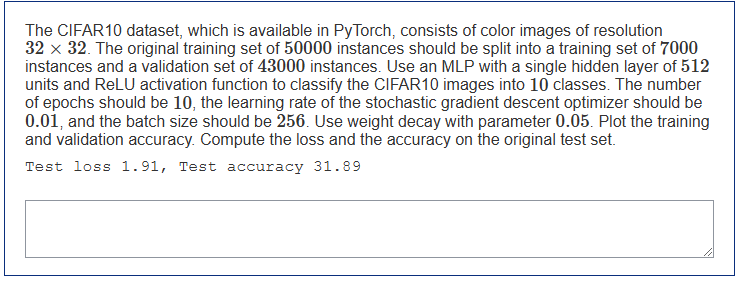

100%|██████████| 170M/170M [00:12<00:00, 13.5MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Epoch [1/10] Train Loss: 2.1888, Train Acc: 20.73% Val Loss: 2.0591,   Val Acc: 26.12%
Epoch [2/10] Train Loss: 1.9925, Train Acc: 29.69% Val Loss: 1.9590,   Val Acc: 30.51%
Epoch [3/10] Train Loss: 1.8983, Train Acc: 33.73% Val Loss: 1.9030,   Val Acc: 32.87%
Epoch [4/10] Train Loss: 1.8424, Train Acc: 36.37% Val Loss: 1.8650,   Val Acc: 34.50%
Epoch [5/10] Train Loss: 1.8002, Train Acc: 38.33% Val Loss: 1.8373,   Val Acc: 35.63%
Epoch [6/10] Train Loss: 1.7635, Train Acc: 40.16% Val Loss: 1.8173,   Val Acc: 36.29%
Epoch [7/10] Train Loss: 1.7413, Train Acc: 41.60% Val Loss: 1.7989,   Val Acc: 37.22%
Epoch [8/10] Train Loss: 1.7142, Train Acc: 42.43% Val Loss: 1.7868,   Val Acc: 37.59%
Epoch [9/10] Train Loss: 1.6920, Train Acc: 43.43% Val Loss: 1.7754,   Val Acc: 37.95%
Epoch [10/10] Train Loss: 1.6759, Train Acc: 44.01% Val Loss: 1.7628,   Val Acc: 38.50%


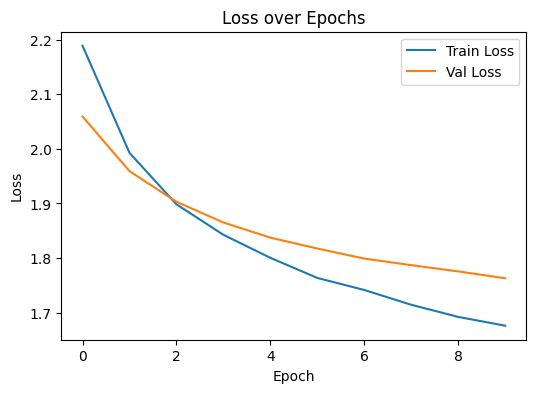

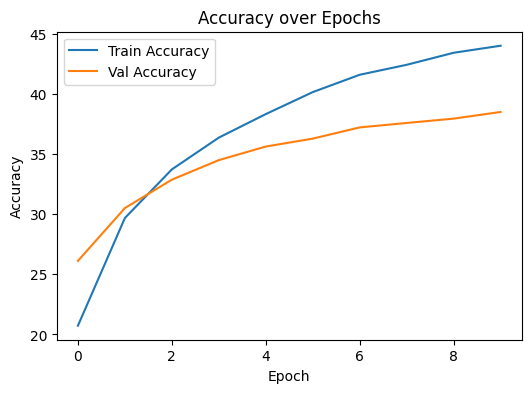


Test Loss: 1.7526, Test Accuracy: 39.06%


In [ ]:
import torch
import torch.nn as nn
import torchvision ho
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = 7000
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 256
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

class MLP(nn.Module):
    def __init__(self, input_dim=32*32*3, hidden_dim=512, output_dim=10):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.05

)

def train(model, train_loader, val_loader, loss_fn, optimizer, epochs=10, device='cpu'):
    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            correct_train += (y_pred.argmax(dim=1) == y).sum().item()

        train_loss = epoch_train_loss / len(train_loader)
        train_acc = 100.0 * correct_train / len(train_loader.dataset)

        model.eval()
        epoch_val_loss = 0
        correct_val = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                y_pred = model(X)
                loss = loss_fn(y_pred, y)

                epoch_val_loss += loss.item()
                correct_val += (y_pred.argmax(dim=1) == y).sum().item()

        val_loss = epoch_val_loss / len(val_loader)
        val_acc = 100.0 * correct_val / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
              f"Val Loss: {val_loss:.4f},   Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 10
train_losses, train_accs, val_losses, val_accs = train(
    model, train_loader, val_loader, loss_fn, optimizer,
    epochs=epochs, device=device
)

def plot_metrics(train_metric, val_metric, metric_name):
    plt.figure(figsize=(6,4))
    plt.plot(train_metric, label=f"Train {metric_name}")
    plt.plot(val_metric, label=f"Val {metric_name}")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} over Epochs")
    plt.legend()
    plt.show()

plot_metrics(train_losses, val_losses, "Loss")
plot_metrics(train_accs, val_accs, "Accuracy")

model.eval()
test_loss = 0
correct = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss = loss_fn(outputs, y)
        test_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y).sum().item()

test_loss /= len(test_loader)
test_accuracy = 100.0 * correct / len(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


# EX 3 :

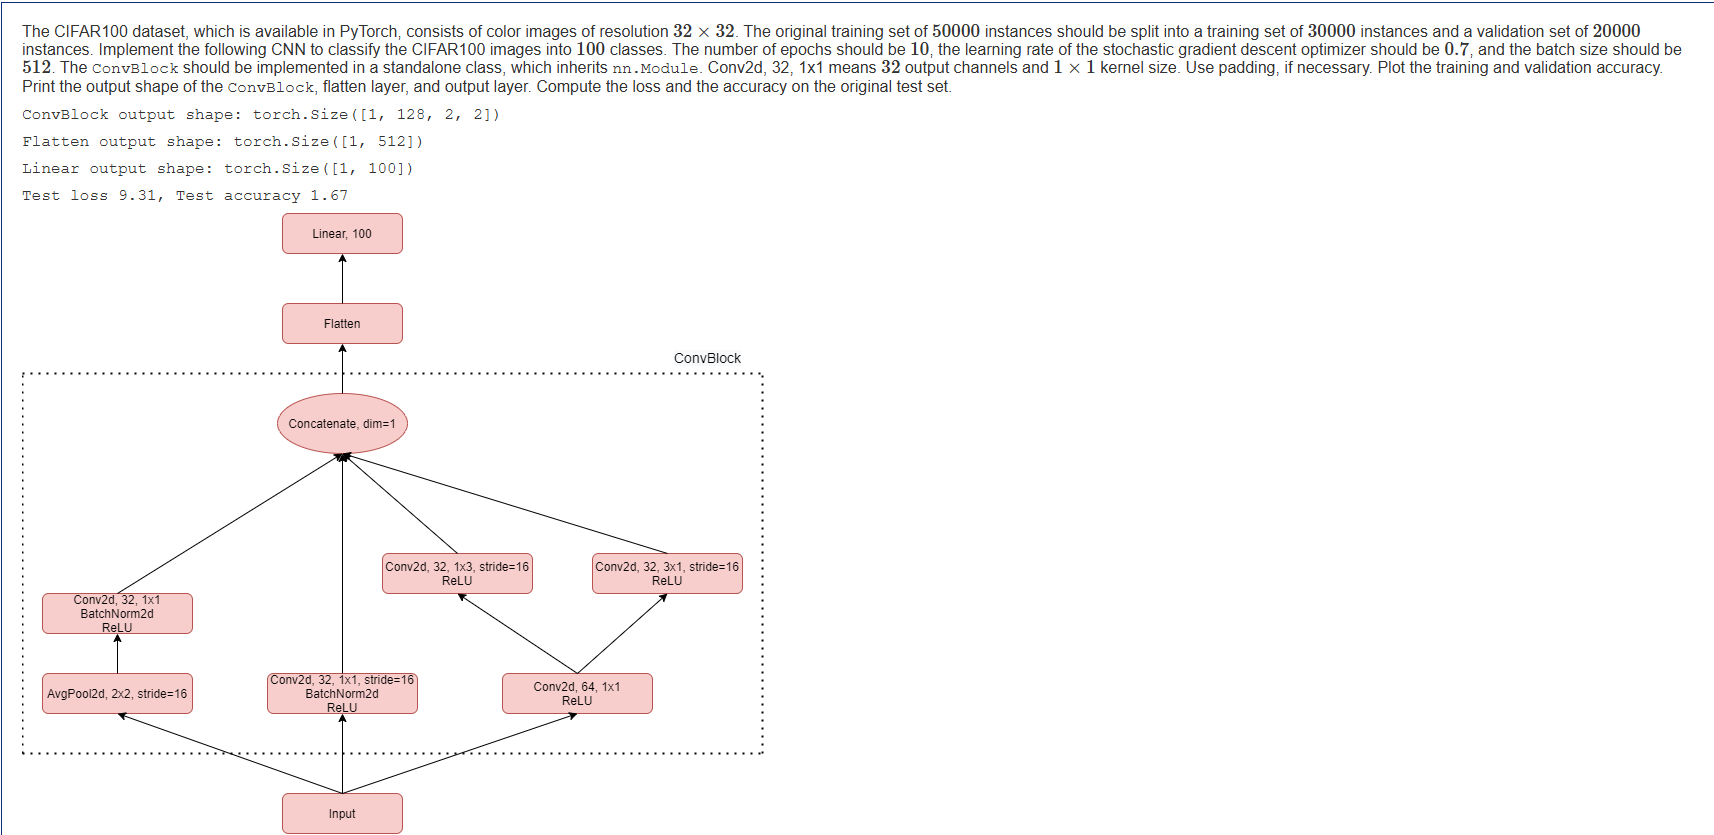

ConvBlock output shape: torch.Size([1, 128, 2, 2])
Flatten output shape: torch.Size([1, 512])
Linear output shape: torch.Size([1, 100])
Files already downloaded and verified
Files already downloaded and verified
Training on cuda:0
Epoch 1, Train loss 4.21, Train accuracy 6.01, Validation loss 4.14, Validation accuracy 6.37
Epoch 2, Train loss 3.97, Train accuracy 9.19, Validation loss 4.26, Validation accuracy 6.35
Epoch 3, Train loss 3.90, Train accuracy 10.11, Validation loss 3.98, Validation accuracy 9.43
Epoch 4, Train loss 3.86, Train accuracy 11.02, Validation loss 4.06, Validation accuracy 9.21
Epoch 5, Train loss 3.83, Train accuracy 11.23, Validation loss 4.01, Validation accuracy 9.04
Epoch 6, Train loss 3.81, Train accuracy 11.46, Validation loss 3.90, Validation accuracy 10.41
Epoch 7, Train loss 3.79, Train accuracy 11.84, Validation loss 3.95, Validation accuracy 9.84
Epoch 8, Train loss 3.78, Train accuracy 11.81, Validation loss 3.99, Validation accuracy 9.81
Epoch 9, T

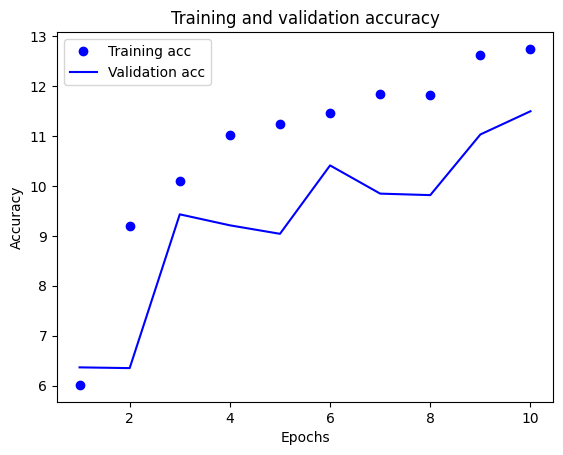

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

def load_data_cifar(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    cifar_train = torchvision.datasets.CIFAR100(
        root="../data", train=True, transform=trans, download=True)
    cifar_test = torchvision.datasets.CIFAR100(
        root="../data", train=False, transform=trans, download=True)
    cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [30000, 20000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(cifar_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(cifar_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(cifar_test, batch_size, shuffle=False,
                            num_workers=2))

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def evaluate_accuracy(net, data_iter, loss, device):
    net.eval()

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

def train_epoch(net, train_iter, loss, optimizer, device):
    net.train()
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

class ConvBlock(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self, input_channels):
        super().__init__()

        self.avgJS = nn.AvgPool2d(kernel_size=2, stride=16)

        self.convJM = nn.Conv2d(input_channels, 32, kernel_size=1, stride=16)
        self.bnJM = nn.BatchNorm2d(32)

        self.convJD = nn.Conv2d(input_channels, 64, kernel_size=1)


        self.convSS = nn.Conv2d(input_channels, 32, kernel_size=1)
        self.bnSS = nn.BatchNorm2d(32)

        self.convSM = nn.Conv2d(64, 32, kernel_size=(1,3), stride=16)

        self.convSD = nn.Conv2d(64, 32, kernel_size=(3,1), stride=16)
    def forward(self, X):
        Y1 = nn.ReLU()(self.bnSS(self.convSS(self.avgJS(X))))
        Y2 = nn.ReLU()(self.bnJM(self.convJM(X)))
        y  = nn.ReLU()(self.convJD(X))
        Y3 = nn.ReLU()(self.convSM(y))
        Y4 = nn.ReLU()(self.convSD(y))

        Y = torch.cat((Y1, Y2, Y3, Y4), 1)

        return Y

conv_block = ConvBlock(3)
x = torch.rand(1, 3, 32, 32)
conv_output = conv_block(x)
print("ConvBlock output shape:", conv_output.shape)

net = nn.Sequential(ConvBlock(3), nn.Flatten(), nn.Linear(512, 100))
x = conv_block(x)
x = torch.flatten(x, start_dim=1)
print("Flatten output shape:", x.shape)
linear_output = net[-1](x)
print("Linear output shape:", linear_output.shape)

batch_size, lr, num_epochs = 512, 0.7, 10
train_iter, val_iter, test_iter = load_data_cifar(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #11 min

def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc_all, val_acc_all)
rX = torch.rand(1, 3, 32, 32, device=try_gpu())


# EX 4 :

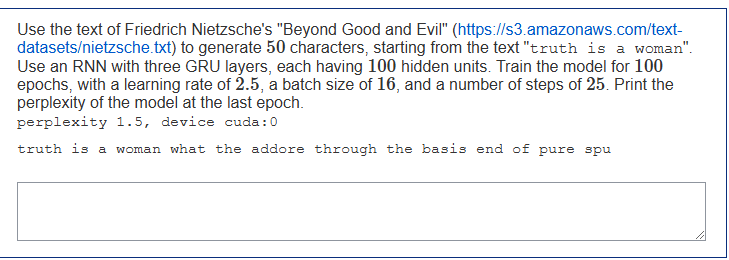


Epoch  10, perplexity 12.88
Sample text: truth is a woman the the the the the the the the the the the the t
----
Epoch  20, perplexity 8.63
Sample text: truth is a womand the was the was the was the was the was the was 
----
Epoch  30, perplexity 5.78
Sample text: truth is a womanity it was a probean that it was be was the probea
----
Epoch  40, perplexity 3.50
Sample text: truth is a woman that the calue of the greater product of theirs b
----
Epoch  50, perplexity 2.05
Sample text: truth is a woman which it is bow andese senning being essentially 
----
Epoch  60, perplexity 1.49
Sample text: truth is a womanity with realing very herselved that it it is atil
----
Epoch  70, perplexity 1.50
Sample text: truth is a woman what the certain is worth more than a foclusion t
----
Epoch  80, perplexity 1.42
Sample text: truth is a woman what the centain thict is to truth the fundamenta
----
Epoch  90, perplexity 1.50
Sample text: truth is a woman whether alror the people produced in evrans in

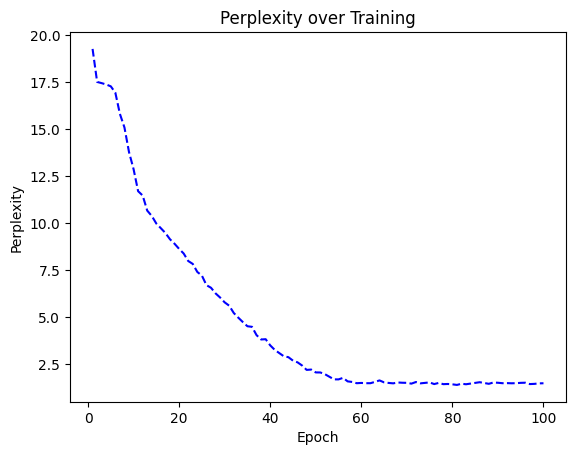

In [ ]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42)

def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def read_nietzsche():
    with open(download('https://s3.amazonaws.com/text-datasets/nietzsche.txt'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

def tokenize(lines, token='char'):
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        return []

class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    if len(tokens) == 0 or isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

def load_corpus_nietzsche(max_tokens=-1):
    lines = read_nietzsche()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

def seq_data_iter_sequential(corpus, batch_size, num_steps):
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

class SeqDataLoader:
    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_nietzsche(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

def load_data_nietzsche(batch_size, num_steps, max_tokens=10000):
    data_iter = SeqDataLoader(batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

class RNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32)
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape(-1, Y.shape[-1]))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            return torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device)
        else:
            return (torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device),
                    torch.zeros((self.rnn.num_layers, batch_size, self.num_hiddens), device=device))

def predict(prefix, num_preds, net, vocab, device):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_epoch(net, train_iter, loss, optimizer, device):
    state = None
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()

        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()

        total_loss += float(l * y.numel())
        total_tokens += y.numel()

    return math.exp(total_loss / total_tokens)

def train(net, train_iter, vocab, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr)
    perplexities = []

    for epoch in range(num_epochs):
        ppl = train_epoch(net, train_iter, loss, optimizer, device)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}, perplexity {ppl:.2f}")
            print("Sample text:", predict('truth is a woman', 50, net, vocab, device))
            print("----")

        perplexities.append(ppl)

    print(f'Final perplexity {ppl:.2f}, device {str(device)}')
    print("Final text sample:", predict('truth is a woman', 50, net, vocab, device))
    return perplexities

def plot_perplexity(perplexities):
    epochs = range(1, len(perplexities) + 1)
    plt.plot(epochs, perplexities, 'b--')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.title('Perplexity over Training')
    plt.show()


if __name__ == "__main__":
    num_layers = 3
    num_hiddens = 100

    batch_size, num_steps = 16, 25
    lr = 2.5
    num_epochs = 100

    train_iter, vocab = load_data_nietzsche(batch_size, num_steps, max_tokens=10000)
    vocab_size = len(vocab)

    gru_layer = nn.GRU(input_size=vocab_size,
                       hidden_size=num_hiddens,
                       num_layers=num_layers)

    net = RNNModel(gru_layer, vocab_size)
    device = try_gpu()
    net.to(device)

    perplexities = train(net, train_iter, vocab, lr, num_epochs, device)

    plot_perplexity(perplexities)


# EX 5 :

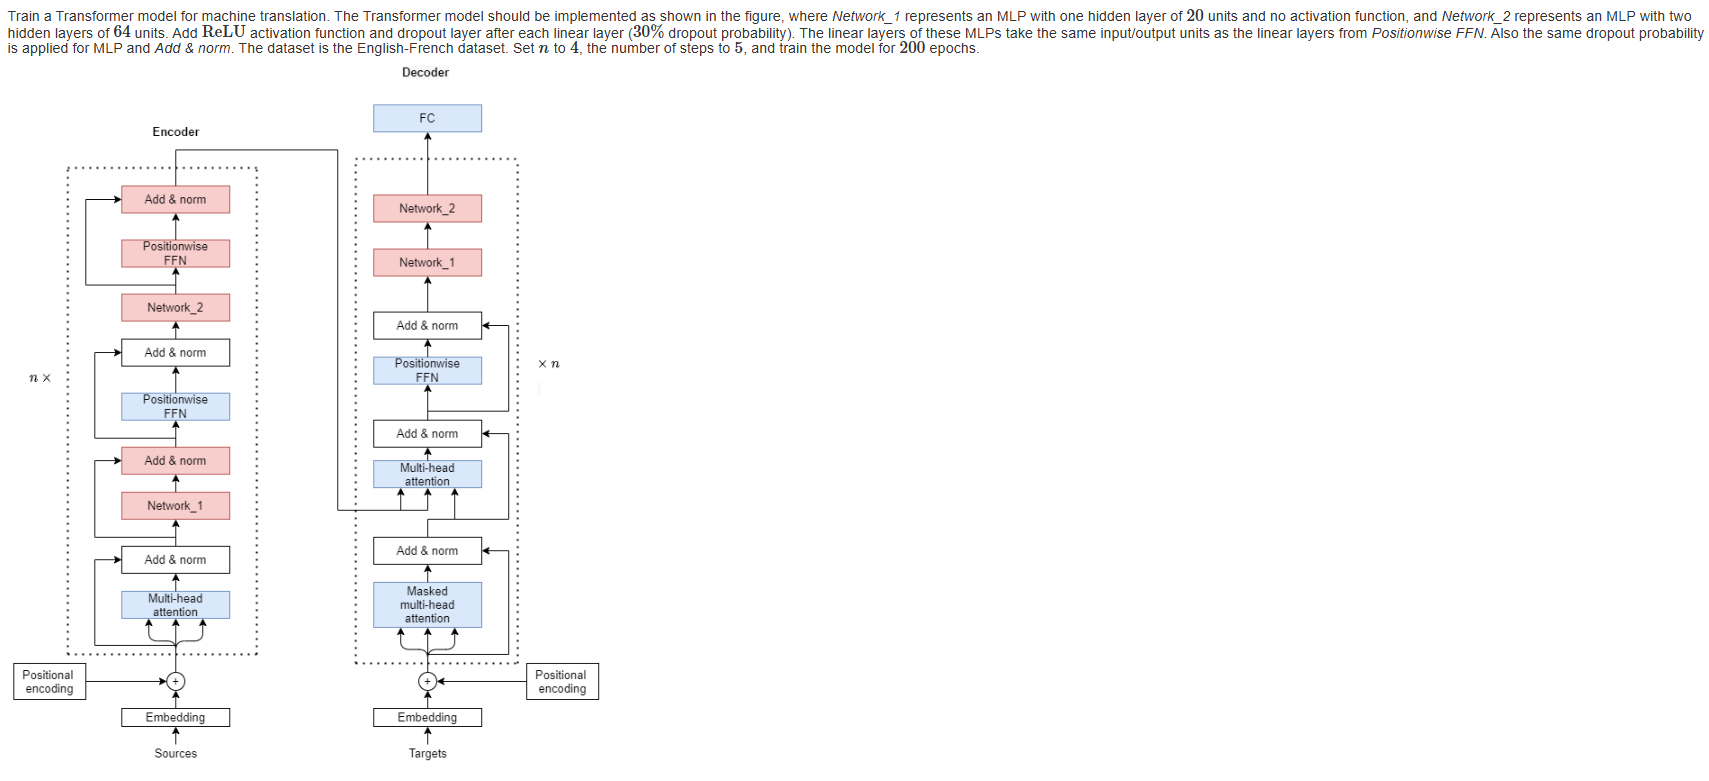

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

torch.manual_seed(42)


def sequence_mask(X, valid_len, value=0):
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                          value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Use `keys.transpose(1,2)` to swap the last two dimensions of `keys`
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


def transpose_qkv(X, num_heads):

    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)


    X = X.permute(0, 2, 1, 3)


    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):

        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:

            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        output = self.attention(queries, keys, values, valid_lens)

        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)


class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)


class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, dropout=0.3):
        super().__init__()
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(
            self.dropout(
                self.relu(
                    self.dense1(X)
                )
            )
        )



class Network1(nn.Module):
    def __init__(self, num_input, num_hidden, num_outputs, **kwargs):
        super().__init__(**kwargs)
        self.hidden = nn.Linear(num_input, num_hidden)
        self.out = nn.Linear(num_hidden, num_outputs)

    def forward(self, X):
        H = self.hidden(X)
        return self.out(H)



class Network2(nn.Module):
    def __init__(self, num_input,num_hiddens, num_outputs, dropout=0.3):
        super().__init__()
        self.layer1 = nn.Linear(num_input, 64)
        self.layer2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, num_outputs)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, X):
        H1 = self.dropout(self.relu(self.layer1(X)))
        H2 = self.dropout(self.relu(self.layer2(H1)))
        return self.dropout(self.output(H2))


class AddNorm(nn.Module):
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)



class Encoder(nn.Module):
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError

class EncoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.network1 = Network1(ffn_num_input, net1_num_hiddens, num_hiddens)
        self.network2 = Network2(ffn_num_input, net2_num_hiddens, num_hiddens, dropout)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.network1(self.attention(X, X, X, valid_lens)))
        Z =  self.addnorm2(Y, self.ffn(Y))
        return self.addnorm3(Z, self.network2(Z))

class TransformerEncoder(Encoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):

        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X


class Decoder(nn.Module):
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

class AttentionDecoder(Decoder):
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

class DecoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)
        self.network2 = Network2(ffn_num_input, net2_num_hiddens, num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]

        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape

            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.network2(self.addnorm1(X, X2))

        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights


class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)


def try_gpu(i=0):
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    if len(tokens) == 0 or isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

def download(url, cache_dir=os.path.join('..', 'data')):
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_nmt():
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip')
    with open(os.path.join(data_dir, 'fra.txt'), 'r') as f:
        return f.read()

def preprocess_nmt(text):
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def tokenize_nmt(text, num_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]  # Truncate
    return line + [padding_token] * (num_steps - len(line))  # Pad

def build_array_nmt(lines, vocab, num_steps):
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

def load_array(data_arrays, batch_size, is_train=True):
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def load_data_nmt(batch_size, num_steps, num_examples=600):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,
                          reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):

    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

def grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    train_loss_all = []
    for epoch in range(num_epochs):
        total_loss = 0
        total_tokens = 0
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                total_loss += l.sum()
                total_tokens += num_tokens
        if (epoch + 1) % 10 == 0:
            train_loss_all.append(total_loss / total_tokens)
    print(f'loss {total_loss / total_tokens:.3f}, device {str(device)}')

    return train_loss_all


num_hiddens, num_layers, dropout, batch_size, num_steps = 64, 4, 0.45, 40, 5
lr, num_epochs, device = 0.005, 200, try_gpu()
ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens, num_heads = 32, 64, 20, 64, 2
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, net1_num_hiddens, net2_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, net2_num_hiddens, num_heads,
    num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

train_loss_all = train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

KeyboardInterrupt: 